In [1]:
# Install required libraries (if not already available in Colab)
!pip install xgboost

# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Clustering & PCA
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [4]:
df = pd.read_csv("/content/Fitbit_dataset.csv")
df.head()


,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,HIIT,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,Yoga,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,Cardio,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14102 entries, 0 to 14101
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     14102 non-null  int64  
 1   Age                            14102 non-null  int64  
 2   Gender                         14102 non-null  object 
 3   Weight (kg)                    14102 non-null  float64
 4   Height (m)                     14102 non-null  float64
 5   Max_BPM                        14102 non-null  float64
 6   Avg_BPM                        14102 non-null  float64
 7   Resting_BPM                    14102 non-null  float64
 8   Session_Duration (hours)       14102 non-null  float64
 9   Workout_Type                   14102 non-null  object 
 10  Fat_Percentage                 14102 non-null  float64
 11  Water_Intake (liters)          14102 non-null  float64
 12  Workout_Frequency (days/week)  14102 non-null 

In [7]:
df.describe()

,Unnamed: 0,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
count,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000
mean,7050.500000,38.528365,68.252922,1.680338,181.400794,147.955538,69.333073,0.830135,21.844313,3.598624,4.150262,1.150546,24.092838,6.726918,0.701554,4.924756,279.492866
std,4071.041083,12.007994,13.330332,0.097543,12.913603,14.628858,7.110206,0.288531,5.974424,0.626391,1.650013,1.057974,3.776271,2.180444,0.100263,2.124242,172.858430
min,0.000000,18.000000,37.800000,1.450000,150.000000,109.000000,55.000000,0.250000,8.000000,1.500000,2.000000,0.000000,18.000000,3.000000,0.539474,1.618421,18.400000
25%,3525.250000,28.000000,58.400000,1.610000,171.000000,137.000000,64.000000,0.620000,17.700000,3.200000,3.000000,0.000000,21.200000,6.000000,0.648000,4.187500,143.200000
50%,7050.500000,39.000000,67.300000,1.680000,181.000000,147.000000,70.000000,0.820000,22.000000,3.600000,4.000000,1.000000,24.000000,7.000000,0.700000,4.550000,251.050000
75%,10575.750000,49.000000,77.000000,1.750000,192.000000,158.000000,75.000000,1.030000,26.100000,4.000000,5.000000,2.000000,26.700000,8.000000,0.752475,6.019802,373.700000
max,14101.000000,59.000000,125.100000,1.900000,205.000000,187.000000,85.000000,1.900000,40.000000,5.900000,7.000000,3.000000,35.000000,9.500000,0.860215,8.172043,1442.400000


In [8]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Gender,0
Weight (kg),0
Height (m),0
Max_BPM,0
Avg_BPM,0
Resting_BPM,0
Session_Duration (hours),0
Workout_Type,0


In [24]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [21]:
categorical_cols = ['Gender', 'Workout_Type', 'Experience_Level']
for col in categorical_cols:
    if col in df.columns:
        df[col] = LabelEncoder().fit_transform(df[col])

In [28]:
target_col = 'Calories_Burned_kcal'
X = df.drop(target_col, axis=1)
y = df[target_col]


In [26]:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("[()]", "", regex=True)

print("Columns:", df.columns.tolist())


Columns: ['Unnamed:_0', 'Age', 'Gender', 'Weight_kg', 'Height_m', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration_hours', 'Workout_Type', 'Fat_Percentage', 'Water_Intake_liters', 'Workout_Frequency_days/week', 'Experience_Level', 'BMI', 'Base_MET', 'HR_Intensity', 'Effective_MET', 'Calories_Burned_kcal']


In [27]:
target_col = 'Calories_Burned_kcal'  # after cleaning

if target_col in df.columns:
    X = df.drop(target_col, axis=1)
    y = df[target_col]
else:
    raise KeyError(f"Target column '{target_col}' not found. Available columns: {df.columns.tolist()}")


In [10]:
print(df.columns)


Index(['Unnamed: 0', 'Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM',
       'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Workout_Type',
       'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Base_MET',
       'HR_Intensity', 'Effective_MET', 'Calories_Burned (kcal)'],
      dtype='object')


In [11]:
df.columns = df.columns.str.strip()


In [12]:
df.rename(columns={'Calories burned': 'Calories_Burned'}, inplace=True)


In [13]:
categorical_cols = ['Gender', 'Workout_Type', 'Experience_Level']
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

In [15]:
print(df.columns.tolist())


['Unnamed: 0', 'Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Base_MET', 'HR_Intensity', 'Effective_MET', 'Calories_Burned (kcal)']


In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [30]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "KNN Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "SVR": SVR(),
    "XGBoost": XGBRegressor()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    }

pd.DataFrame(results).T



,MAE,RMSE,R2
Linear Regression,34.626756,52.784061,0.911258
Ridge Regression,34.628564,52.786036,0.911252
Lasso Regression,34.895241,53.718593,0.908088
KNN Regressor,31.827735,45.637020,0.933663
Decision Tree,8.354165,13.918128,0.993830
Random Forest,3.936202,8.192185,0.997862
SVR,32.827902,64.777398,0.866350
XGBoost,5.314001,8.070494,0.997925


In [33]:
target_col = 'Calories_Burned_kcal'
if target_col in df.columns:
    X_cluster = df.drop(target_col, axis=1)
else:
    raise KeyError(f"Target column '{target_col}' not found. Available columns: {df.columns.tolist()}")

In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [35]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [36]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

In [37]:
score = silhouette_score(X_pca, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.4216016317059872


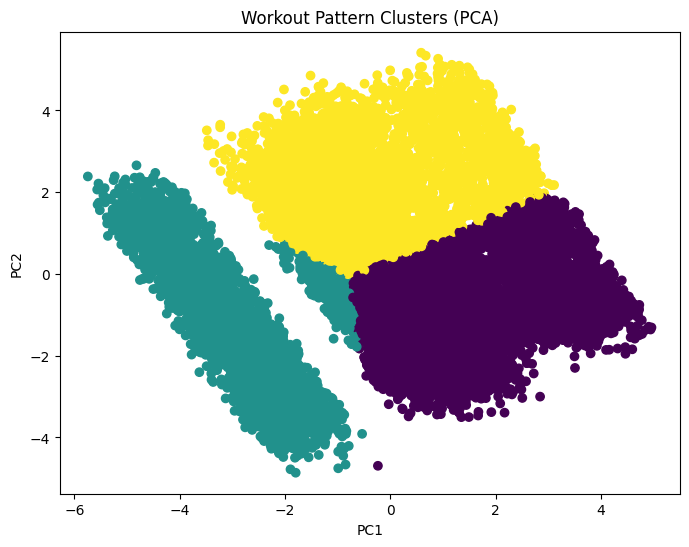

In [38]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title("Workout Pattern Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [39]:
cluster_df = pd.DataFrame(X_cluster)
cluster_df['Cluster'] = clusters
print(cluster_df.groupby('Cluster').mean())

          Unnamed:_0        Age    Gender  Weight_kg  Height_m     Max_BPM  \
Cluster                                                                      
0        7068.177424  38.015909  0.492121  68.369121  1.680397  182.059545   
1        7036.573554  39.723636  0.495207  68.530545  1.682136  179.903140   
2        7033.849676  38.476212  0.530713  67.894036  1.679035  181.441590   

            Avg_BPM  Resting_BPM  Session_Duration_hours  Workout_Type  \
Cluster                                                                  
0        153.613939    73.276515                0.664938      1.428939   
1        131.369256    69.377521                0.825365      3.914380   
2        150.820862    63.489614                1.076891      1.533170   

         Fat_Percentage  Water_Intake_liters  Workout_Frequency_days/week  \
Cluster                                                                     
0             25.058000             3.284864                     3.083636   
1      

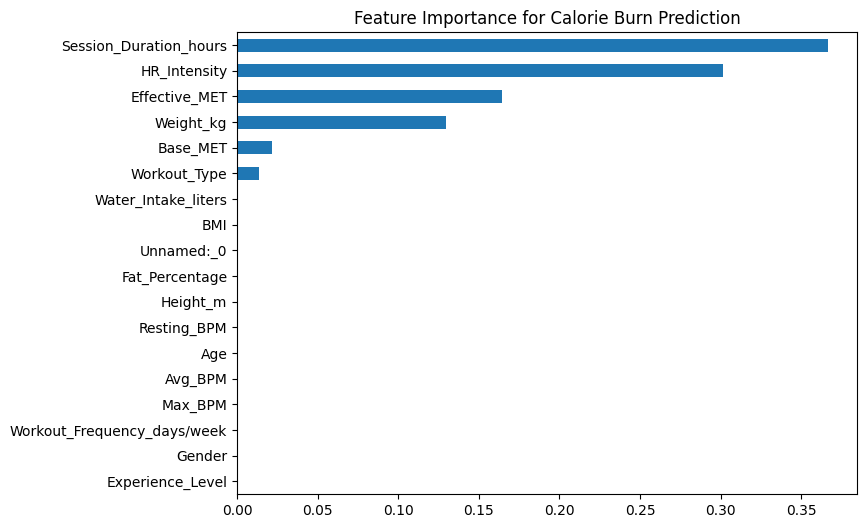

In [41]:

rf = RandomForestRegressor().fit(X_train, y_train)

target_col = 'Calories_Burned_kcal'
importances = pd.Series(
    rf.feature_importances_,
    index=df.drop(target_col, axis=1).columns
)

importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance for Calorie Burn Prediction")
plt.show()


In [42]:
target_col = 'Calories_Burned_kcal'


In [43]:
df.describe(include='all')


,Unnamed:_0,Age,Gender,Weight_kg,Height_m,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration_hours,Workout_Type,Fat_Percentage,Water_Intake_liters,Workout_Frequency_days/week,Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned_kcal
count,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000
mean,7050.500000,38.528365,0.505035,68.252922,1.680338,181.400794,147.955538,69.333073,0.830135,1.995178,21.844313,3.598624,4.150262,1.150546,24.092838,6.726918,0.701554,4.924756,279.492866
std,4071.041083,12.007994,0.499992,13.330332,0.097543,12.913603,14.628858,7.110206,0.288531,1.406915,5.974424,0.626391,1.650013,1.057974,3.776271,2.180444,0.100263,2.124242,172.858430
min,0.000000,18.000000,0.000000,37.800000,1.450000,150.000000,109.000000,55.000000,0.250000,0.000000,8.000000,1.500000,2.000000,0.000000,18.000000,3.000000,0.539474,1.618421,18.400000
25%,3525.250000,28.000000,0.000000,58.400000,1.610000,171.000000,137.000000,64.000000,0.620000,1.000000,17.700000,3.200000,3.000000,0.000000,21.200000,6.000000,0.648000,4.187500,143.200000
50%,7050.500000,39.000000,1.000000,67.300000,1.680000,181.000000,147.000000,70.000000,0.820000,2.000000,22.000000,3.600000,4.000000,1.000000,24.000000,7.000000,0.700000,4.550000,251.050000
75%,10575.750000,49.000000,1.000000,77.000000,1.750000,192.000000,158.000000,75.000000,1.030000,3.000000,26.100000,4.000000,5.000000,2.000000,26.700000,8.000000,0.752475,6.019802,373.700000
max,14101.000000,59.000000,1.000000,125.100000,1.900000,205.000000,187.000000,85.000000,1.900000,4.000000,40.000000,5.900000,7.000000,3.000000,35.000000,9.500000,0.860215,8.172043,1442.400000


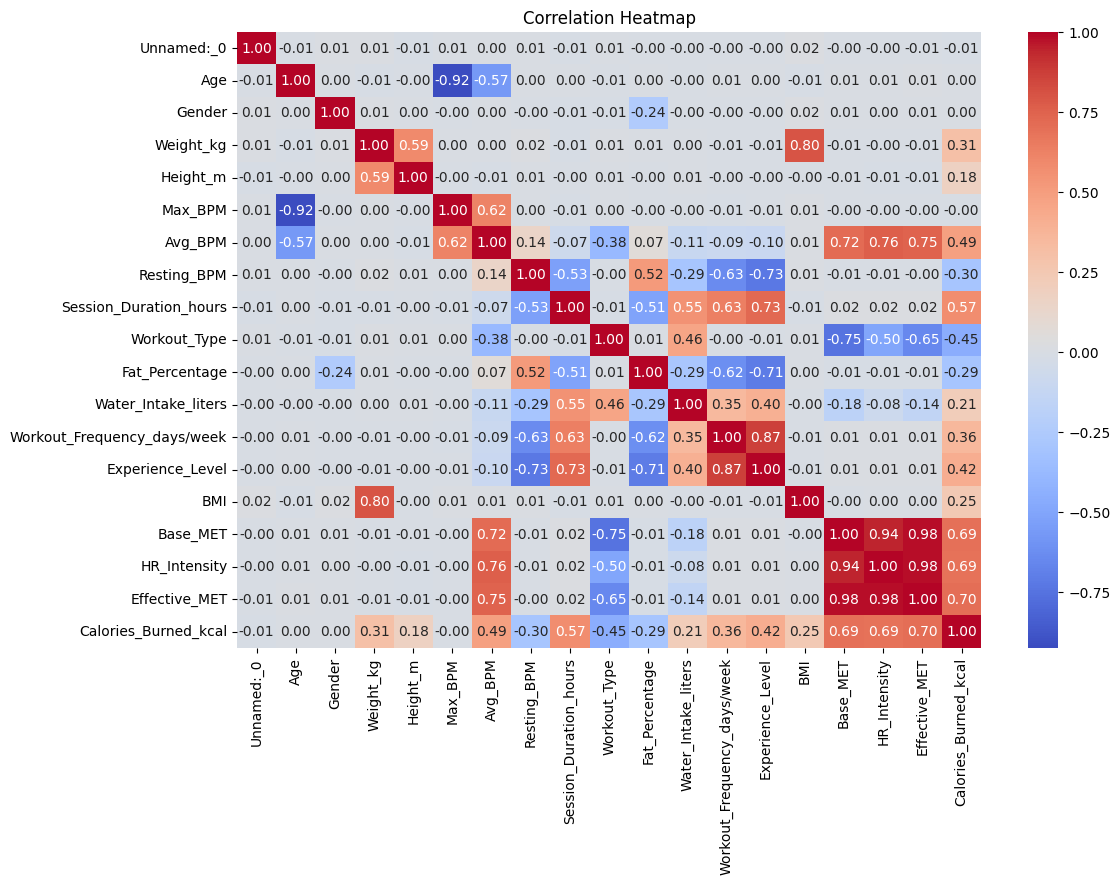

In [44]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


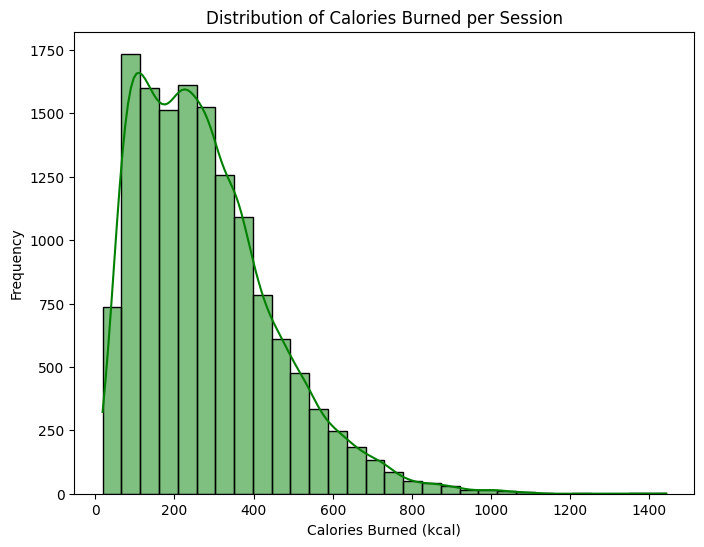

In [45]:
plt.figure(figsize=(8,6))
sns.histplot(df['Calories_Burned_kcal'], bins=30, kde=True, color="green")
plt.title("Distribution of Calories Burned per Session")
plt.xlabel("Calories Burned (kcal)")
plt.ylabel("Frequency")
plt.show()


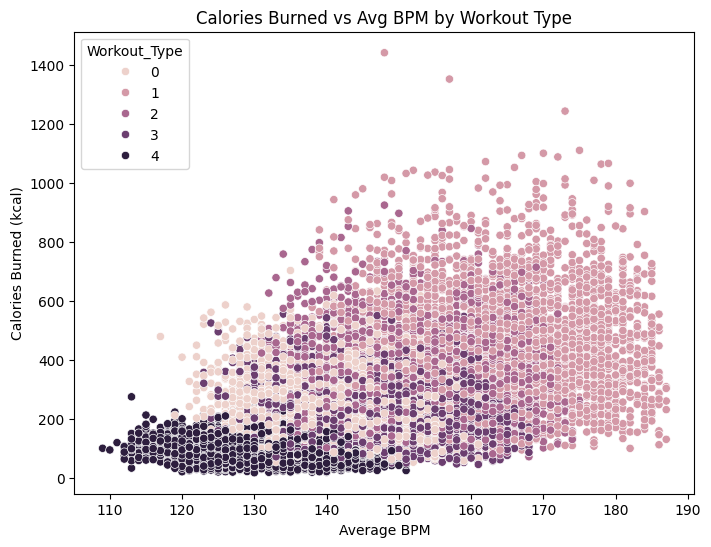

In [46]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Avg_BPM'], y=df['Calories_Burned_kcal'], hue=df['Workout_Type'])
plt.title("Calories Burned vs Avg BPM by Workout Type")
plt.xlabel("Average BPM")
plt.ylabel("Calories Burned (kcal)")
plt.show()


In [47]:
results_df = pd.DataFrame(results).T

/tmp/ipykernel_1293/88334459.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['R2'], palette="viridis")


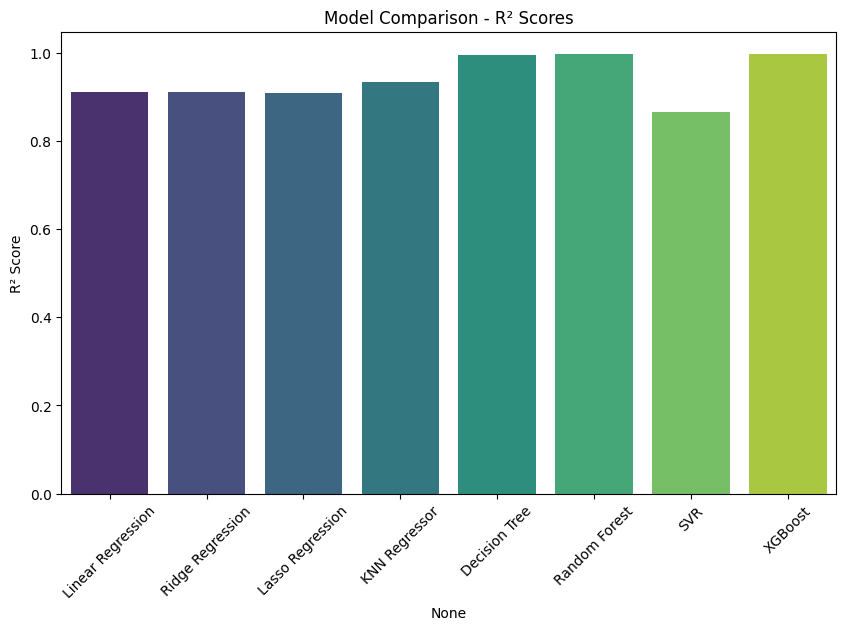

In [48]:
plt.figure(figsize=(10,6))
sns.barplot(x=results_df.index, y=results_df['R2'], palette="viridis")
plt.xticks(rotation=45)
plt.title("Model Comparison - R² Scores")
plt.ylabel("R² Score")
plt.show()

/tmp/ipykernel_1293/2062866931.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['RMSE'], palette="magma")


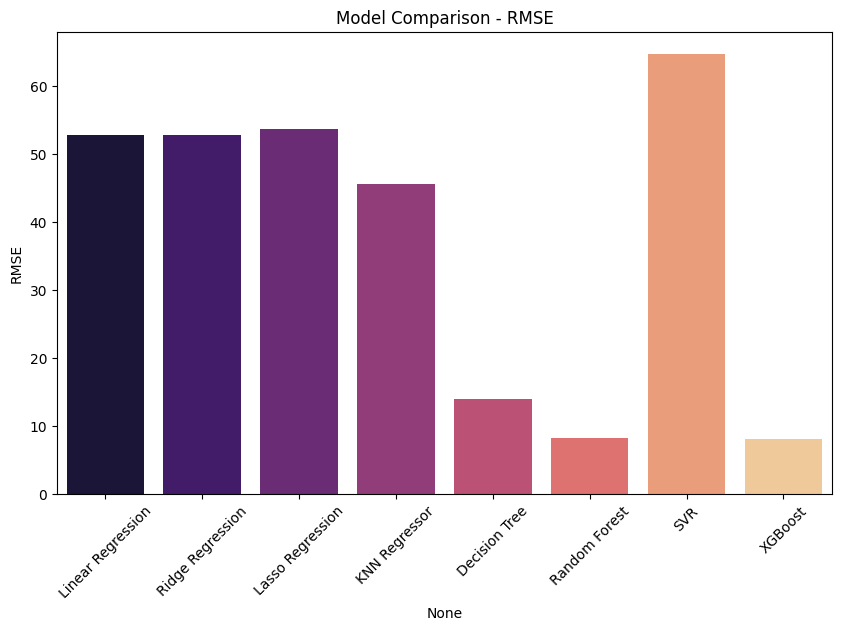

In [49]:
plt.figure(figsize=(10,6))
sns.barplot(x=results_df.index, y=results_df['RMSE'], palette="magma")
plt.xticks(rotation=45)
plt.title("Model Comparison - RMSE")
plt.ylabel("RMSE")
plt.show()

In [50]:
best_model_name = results_df['R2'].idxmax()
print("Best model:", best_model_name)

best_model = models[best_model_name]
best_model.fit(X_train, y_train)


Best model: XGBoost


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [52]:

new_data = pd.DataFrame({
    'Age': [28],
    'Gender': [1],
    'Weight_kg': [70],
    'Height_m': [1.75],
    'Max_BPM': [180],
    'Avg_BPM': [150],
    'Resting_BPM': [65],
    'Session_Duration_hours': [1],
    'Workout_Type': [2],
    'Fat_Percentage': [18],
    'Water_Intake_liters': [1.5],
    'Workout_Frequency_days/week': [4],
    'Experience_Level': [1],
    'BMI': [22.9],
    'Base_MET': [6],
    'HR_Intensity': [0.8],
    'Effective_MET': [7.2]
}, columns=X.columns)

